<a href="https://colab.research.google.com/github/jwlee95/DSP_w_Python2026/blob/main/PDSP_ch03_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3장 예제:   

- 컨볼루션 합의 직접 계산(Algorithm 3.1), 그 결과를 numpy.convolve와 비교 검증,   
- 1차 IIR 차분방정식(지수 평활)의 재귀적 구현과 scipy.signal.lfilter 비교,   
- 그리고 이동평균 필터를 이용한 잡음 신호 평활화 응용까지를 포함한다.   

> 필요 라이브러리: numpy, scipy, matplotlib  (pip install numpy scipy matplotlib)


In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

### 라이브러리 설명:

*   **`numpy as np`**: NumPy는 파이썬에서 과학 계산을 위한 핵심 라이브러리입니다. 다차원 배열 객체와 배열 작업을 위한 도구를 제공하여, 복잡한 수학적 연산을 효율적으로 수행할 수 있게 합니다.
*   **`scipy as signal`**: SciPy는 과학 및 기술 계산을 위한 파이썬 라이브러리입니다. 여기서는 `signal` 모듈을 `signal`이라는 이름으로 임포트하여 신호 처리 기능을 사용합니다. 예를 들어, 필터링 함수인 `lfilter` 등을 활용합니다.
*   **`matplotlib.pyplot as plt`**: Matplotlib는 파이썬에서 정적, 애니메이션 및 인터랙티브 시각화를 생성하기 위한 포괄적인 라이브러리입니다. `pyplot` 모듈을 `plt`라는 이름으로 임포트하여 그래프 및 차트 그리기 기능을 사용합니다.

In [2]:
def discrete_convolution(x: np.ndarray, h: np.ndarray, nx0: int = 0, nh0: int = 0):
    """
    Algorithm 3.1을 그대로 구현한 컨볼루션 합 계산 함수.
    x, h: 1차원 배열 (각각 인덱스 nx0, nh0에서 시작한다고 가정)
    반환값: (y, ny0)  y는 결과 배열, ny0는 (3.19)에 따른 y의 시작 인덱스
    """
    Nx = len(x)
    Nh = len(h)
    Ny = Nx + Nh - 1
    ny0 = nx0 + nh0
    y = np.zeros(Ny)
    for i in range(Ny):
        k_min = max(0, i - Nh + 1)
        k_max = min(i, Nx - 1)
        acc = 0.0
        for k in range(k_min, k_max + 1):
            acc += x[k] * h[i - k]
        y[i] = acc
    return y, ny0


### `discrete_convolution` 함수 상세 설명

이 함수는 이산 신호 처리의 핵심 연산인 **컨볼루션 합(Convolution Sum)**을 직접 구현한 것입니다.

**1. 주요 매개변수:**
*   `x`: 입력 신호 배열 (크기 $N_x$)
*   `h`: 임펄스 응답 배열 (크기 $N_h$)
*   `nx0`, `nh0`: 각 배열의 첫 번째 원소가 대응하는 시간 인덱스 $n$의 값입니다. 기본값은 0입니다.

**2. 연산 원리:**
*   **결과 길이**: 두 신호를 컨볼루션하면 결과 신호 $y[n]$의 길이는 $N_x + N_h - 1$이 됩니다.
*   **시작 인덱스**: 결과 신호의 시작 인덱스 $ny_0$는 두 입력 신호의 시작 인덱스 합인 $nx_0 + nh_0$와 같습니다.
*   **중첩 루프**: 수식 $y[n] = \sum_{k} x[k]h[n-k]$를 계산하기 위해 이중 루프를 사용합니다.
    *   바깥쪽 루프(`i`): 결과 배열 $y$의 모든 인덱스를 순회합니다.
    *   안쪽 루프(`k`): $x[k]$와 $h[n-k]$가 모두 존재하는 유효한 범위를 찾아 곱셈과 누적(MAC) 연산을 수행합니다.

**3. 활용:**
*   이 구현은 `numpy.convolve`와 동일한 결과를 내며, 알고리즘의 내부 동작을 이해하는 데 유용합니다.

In [3]:
def moving_average_filter(M: int) -> np.ndarray:
    """길이 M의 이동평균 필터(FIR 임펄스응답)를 반환한다. h[n] = 1/M, n = 0,...,M-1 (식 3.22)."""
    return np.ones(M) / M


### `moving_average_filter` 함수 상세 설명

이 함수는 신호의 고주파 잡음을 제거하고 흐름을 매끄럽게 만드는 **이동평균 필터**의 임펄스 응답(Impulse Response)을 생성합니다.

**1. 수학적 정의:**
길이가 $M$인 이동평균 필터의 임펄스 응답 $h[n]$은 다음과 같이 정의됩니다 (식 3.22):

$$
h[n] =
\begin{cases}
\frac{1}{M}, & 0 \le n \le M-1 \\
0, & \text{otherwise}
\end{cases}
$$

**2. 차분 방정식:**
이 필터의 출력 $y[n]$은 입력 $x[n]$에 대해 다음과 같은 평균값으로 계산됩니다:

$$
y[n] = \frac{1}{M} \sum_{k=0}^{M-1} x[n-k]
$$

**3. 함수의 동작:**
*   `np.ones(M)`을 통해 크기가 1인 원소 $M$개를 가진 배열을 생성합니다.
*   생성된 배열을 $M$으로 나누어 모든 계수의 합이 1이 되도록 정규화합니다. 이는 필터를 통과한 신호의 전체 에너지를 유지하기 위함입니다.

In [4]:
def exponential_smoothing_iir(x: np.ndarray, alpha: float, y_init: float = 0.0) -> np.ndarray:
    """
    1차 IIR 차분방정식 y[n] = alpha*y[n-1] + (1-alpha)*x[n] (식 3.23)을
    재귀적으로 직접 계산한다. y_init은 초기조건 y[-1]에 해당한다.
    """
    y = np.zeros_like(x, dtype=float)
    y_prev = y_init
    for n in range(len(x)):
        y[n] = alpha * y_prev + (1 - alpha) * x[n]
        y_prev = y[n]
    return y

### `exponential_smoothing_iir` 함수 상세 설명

이 함수는 1차 **IIR(Infinite Impulse Response) 필터**의 일종인 지수 평활법을 차분 방정식을 통해 직접 구현한 것입니다.

**1. 수학적 정의 (차분 방정식):**
지수 평활 필터의 출력 $y[n]$은 현재의 입력 $x[n]$과 바로 이전의 출력 $y[n-1]$의 가중치 합으로 계산됩니다 (식 3.23):

$$
y[n] = \alpha \cdot y[n-1] + (1 - \alpha) \cdot x[n]
$$

여기서 $\alpha$는 **평활 계수(Smoothing Factor)**로, $0 \le \alpha < 1$ 사이의 값을 가집니다.

**2. 주요 매개변수:**
*   `x`: 입력 신호 배열
*   `alpha` ($\alpha$): 이전 출력값의 반영 비율입니다. 1에 가까울수록 더 많이 평활(Smoothing)되어 잡음은 줄어들지만 신호의 지연이 커집니다.
*   `y_init`: 초기 조건 $y[-1]$ 값입니다. 기본값은 0.0입니다.

**3. 함수의 특징:**
*   **재귀적 구조**: 현재 값이 이전 결과값에 의존하는 재귀적(Recursive) 특성을 가집니다.
*   **IIR 필터**: 이론적으로 임펄스 응답이 무한히 지속되는 IIR 필터의 가장 단순한 형태입니다.
*   **실시간 처리**: 이전 데이터의 평균을 저장할 필요 없이 직전의 출력값 하나만 유지하면 되므로 메모리 효율적입니다.

---

### 메인 실행 블록 (`__main__`) 설명

이 섹션에서는 앞에서 정의한 함수들을 사용하여 실제 데이터를 처리하고 결과를 검증합니다.

**1. 컨볼루션 합 검증**:
*   입력 $x = [1, 2, 3]$과 임펄스 응답 $h = [1, 1, 1]$을 사용하여 직접 구현한 `discrete_convolution` 결과와 NumPy의 표준 함수인 `np.convolve` 결과를 비교하여 알고리즘의 정확성을 확인합니다.

**2. IIR 지수 평활 검증**:
*   노이즈가 섞인 사인파 신호를 생성합니다.
*   직접 구현한 재귀 함수 `exponential_smoothing_iir`와 SciPy의 표준 필터링 함수인 `signal.lfilter` 결과가 일치하는지 확인하여 차분 방정식 구현의 타당성을 검증합니다.

**3. FIR 이동평균 필터 적용**:
*   길이 $M=9$인 이동평균 필터를 생성하고, 컨볼루션 연산을 통해 노이즈 신호를 부드럽게 필터링합니다.

**4. 시각화**:
*   **첫 번째 그래프**: 원본 깨끗한 신호와 노이즈가 추가된 입력 신호를 보여줍니다.
*   **두 번째 그래프**: FIR 이동평균 필터를 통과한 결과를 보여줍니다. 신호가 부드러워지지만 위상 지연이 발생하는 것을 확인할 수 있습니다.
*   **세 번째 그래프**: IIR 지수 평활 필터를 통과한 결과를 보여줍니다. 설정된 $\alpha$ 값에 따른 필터링 효과를 시각적으로 비교합니다.

=== (1) 컨볼루션 손계산 예시 검증 ===
Algorithm 3.1 결과 : [1. 3. 6. 5. 3.]  (시작 인덱스 n=0)
np.convolve 결과   : [1. 3. 6. 5. 3.]
두 결과 일치 여부   : True

=== (2) IIR 차분방정식(지수 평활) 검증 ===
직접 재귀 계산과 scipy.signal.lfilter 결과 일치 여부: True


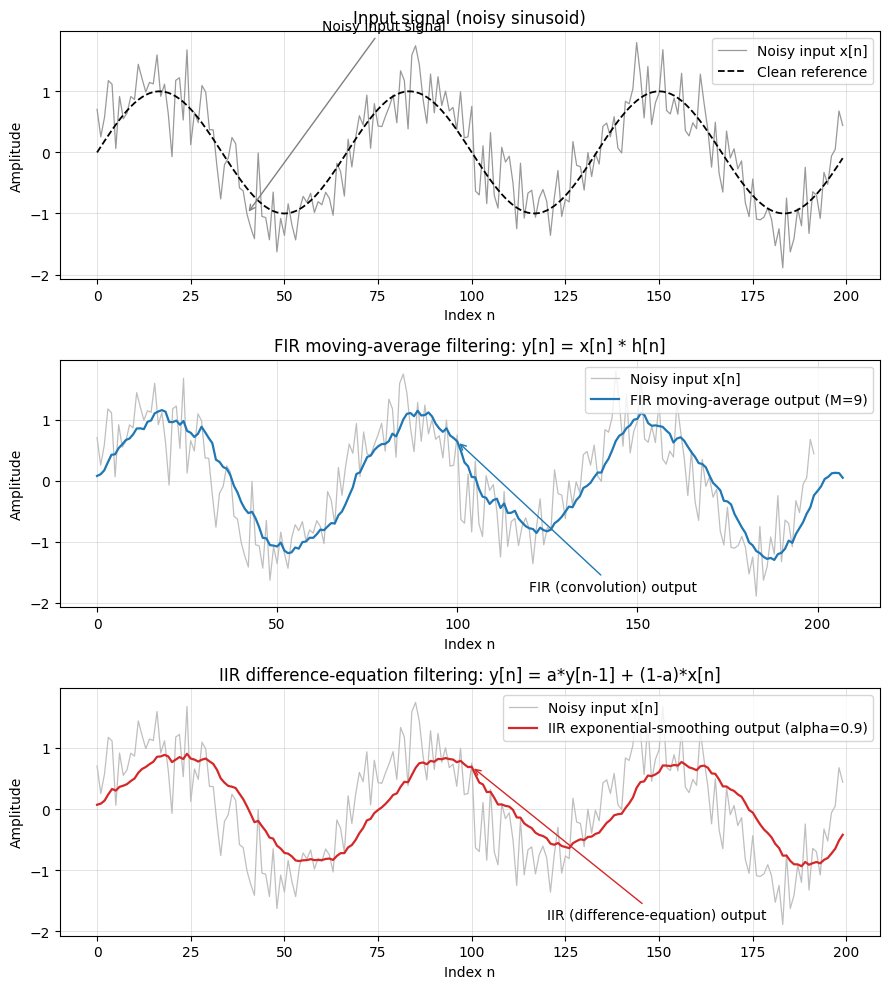

In [5]:
if __name__ == "__main__":
    # ------------------------------------------------------------------
    # (1) 3.3.2절 손계산 예시 검증: x=[1,2,3], h=[1,1,1]
    # ------------------------------------------------------------------
    x_demo = np.array([1.0, 2.0, 3.0])
    h_demo = np.array([1.0, 1.0, 1.0])
    y_algo, ny0_demo = discrete_convolution(x_demo, h_demo)
    y_ref = np.convolve(x_demo, h_demo, mode='full')
    print("=== (1) 컨볼루션 손계산 예시 검증 ===")
    print(f"Algorithm 3.1 결과 : {y_algo}  (시작 인덱스 n={ny0_demo})")
    print(f"np.convolve 결과   : {y_ref}")
    print(f"두 결과 일치 여부   : {np.allclose(y_algo, y_ref)}")

    # ------------------------------------------------------------------
    # (2) 1차 IIR 차분방정식: 직접 재귀 계산 vs scipy.signal.lfilter
    # ------------------------------------------------------------------
    np.random.seed(0)
    n = np.arange(0, 200)
    fs = 200.0
    f0 = 3.0
    clean_signal = np.sin(2 * np.pi * f0 * n / fs)
    noisy_signal = clean_signal + 0.4 * np.random.randn(len(n))

    alpha = 0.9
    y_iir_direct = exponential_smoothing_iir(noisy_signal, alpha)
    b_coef = [1 - alpha]
    a_coef = [1, -alpha]
    y_iir_scipy = signal.lfilter(b_coef, a_coef, noisy_signal)
    print("\n=== (2) IIR 차분방정식(지수 평활) 검증 ===")
    print(f"직접 재귀 계산과 scipy.signal.lfilter 결과 일치 여부: "
          f"{np.allclose(y_iir_direct, y_iir_scipy)}")

    # ------------------------------------------------------------------
    # (3) FIR 이동평균 필터를 이용한 잡음 평활화 (3.8절 응용 사례에서 해석)
    # ------------------------------------------------------------------
    M = 9
    h_ma = moving_average_filter(M)
    y_ma, ny0_ma = discrete_convolution(noisy_signal, h_ma)
    n_ma = np.arange(ny0_ma, ny0_ma + len(y_ma))

    # ------------------------------------------------------------------
    # (4) 시각화
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(3, 1, figsize=(9, 10), facecolor='white')
    for ax in axes:
        ax.set_facecolor('white')
        ax.grid(True, linewidth=0.5, alpha=0.5)

    axes[0].plot(n, noisy_signal, color='0.6', linewidth=0.9, label='Noisy input x[n]')
    axes[0].plot(n, clean_signal, color='black', linewidth=1.3, linestyle='--',
                 label='Clean reference')
    axes[0].set_title('Input signal (noisy sinusoid)')
    axes[0].set_xlabel('Index n')
    axes[0].set_ylabel('Amplitude')
    axes[0].annotate('Noisy input signal', xy=(40, noisy_signal[40]),
                      xytext=(60, 2.0), arrowprops=dict(arrowstyle='->', color='gray'))
    axes[0].legend(loc='upper right')

    axes[1].plot(n, noisy_signal, color='0.75', linewidth=0.9, label='Noisy input x[n]')
    axes[1].plot(n_ma, y_ma, color='tab:blue', linewidth=1.6,
                 label=f'FIR moving-average output (M={M})')
    axes[1].set_title('FIR moving-average filtering: y[n] = x[n] * h[n]')
    axes[1].set_xlabel('Index n')
    axes[1].set_ylabel('Amplitude')
    axes[1].annotate('FIR (convolution) output', xy=(100, y_ma[100]),
                      xytext=(120, -1.8), arrowprops=dict(arrowstyle='->', color='tab:blue'))
    axes[1].legend(loc='upper right')

    axes[2].plot(n, noisy_signal, color='0.75', linewidth=0.9, label='Noisy input x[n]')
    axes[2].plot(n, y_iir_direct, color='tab:red', linewidth=1.6,
                 label=f'IIR exponential-smoothing output (alpha={alpha})')
    axes[2].set_title('IIR difference-equation filtering: y[n] = a*y[n-1] + (1-a)*x[n]')
    axes[2].set_xlabel('Index n')
    axes[2].set_ylabel('Amplitude')
    axes[2].annotate('IIR (difference-equation) output', xy=(100, y_iir_direct[100]),
                      xytext=(120, -1.8), arrowprops=dict(arrowstyle='->', color='tab:red'))
    axes[2].legend(loc='upper right')

    fig.tight_layout()
    plt.show()